# Longitudinal Autism Study: Multilevel and Marginal Regression Analysis

This notebook provides a comprehensive statistical analysis of longitudinal data from a study focusing on the social development of children with autism. Using a dataset that tracks children from ages 2 to 13, the analysis explores how socialization scores (measured via the Vineland Social Age Equivalent) evolve over time and across different diagnostic groups.

### Objectives

The primary goal of this analysis is to model the correlation inherent in repeated measures data. Because each child is observed multiple times, standard linear regression is inappropriate as it assumes independence between observations. To address this, we implement and compare two sophisticated statistical frameworks:

1. **Multilevel Modeling (Random Effects):** This approach accounts for subject-specific variation by incorporating explicit random effects for each child, allowing for individual-level differences in baseline scores and growth trajectories.

2. **Marginal Regression (Generalized Estimating Equations):** This approach focuses on the population-average effects. We utilize an "Exchangeable" correlation structure and robust "sandwich" estimators to ensure valid statistical inference even if the underlying correlation is complex.

### Data Overview

The dataset consists of 612 longitudinal observations. Key variables include:

* **`childid`**: Unique identifier for each participant.
* **`age`**: The child's age at the time of assessment.
* **`vsae`**: The Vineland Social Age Equivalent score (the primary outcome).
* **`sicdegp`**: A categorical grouping variable representing different diagnostic or initial severity levels.

### Methodology

The notebook follows a structured data science workflow:

* **Data Preparation:** Cleaning and sorting the data by `childid` to meet the requirements of longitudinal modeling in `statsmodels`.
* **Exploratory Data Analysis (EDA):** Visualizing the relationship between age, group membership, and socialization scores using scatterplots and boxplots.
* **Statistical Modeling:** Fitting both the Mixed-Effects and GEE models to the data.
* **Interpretation:** Comparing the point estimates and significance levels (p-values) across both modeling techniques to understand the impact of age and group classification on social development.

## Importing libraries and reading data
Before we begin, we need to import a few libraries:

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Next we read the data and drop cases with missing values.

In [2]:
# Load the dataset
df = pd.read_csv("autism.csv")

# Check for missing values before cleaning
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age        0
vsae       2
sicdegp    0
childid    0
dtype: int64


Remove rows where `vsae` is missing

In [3]:
# Since we only have 2 missing values, dropping them is a safe approach.
df = df.dropna(subset=['vsae'])

# Verify the cleaning
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age        0
vsae       0
sicdegp    0
childid    0
dtype: int64


The first few rows of data apper as follows:

In [4]:
df.head()

,age,vsae,sicdegp,childid
0,2,6.0,3,1
1,3,7.0,3,1
2,5,18.0,3,1
3,9,25.0,3,1
4,13,27.0,3,1


## Visualizing the relationship between socialization level `vsae` and `age`.

We will create a set of plots: a scatterplot to see individual data points and a series of boxplots to better understand the distribution of scores at each distinct age level.

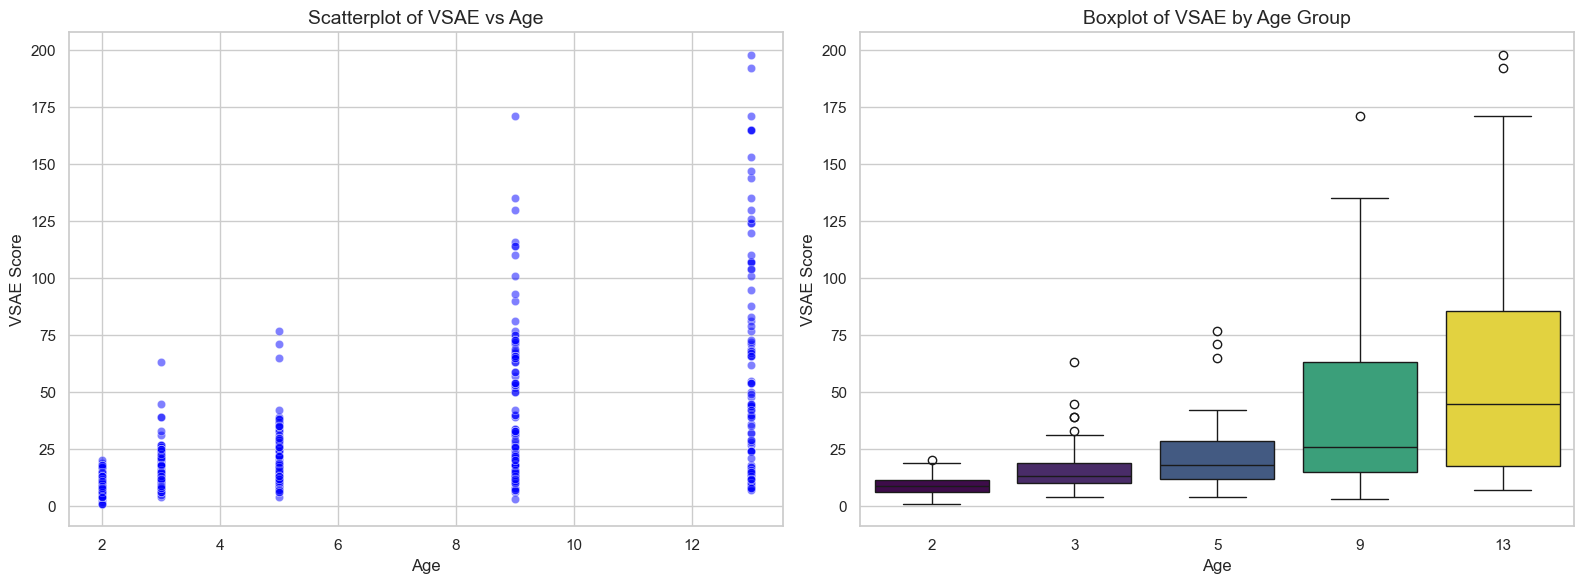

In [5]:
# Setting the visual style
sns.set_theme(style='whitegrid')

# Create a figure with two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Scatterplot
sns.scatterplot(data=df, x='age', y='vsae', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('Scatterplot of VSAE vs Age', fontsize=14)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('VSAE Score', fontsize=12)

# Subplot 2: Boxplots
sns.boxplot(data=df, x='age', y='vsae', ax=axes[1], palette='viridis', hue='age',
            legend=False)
axes[1].set_title('Boxplot of VSAE by Age Group', fontsize=14)
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_ylabel('VSAE Score', fontsize=12)

# Adjust layout and save image
plt.tight_layout()
plt.savefig('vsae_age_visualization.png')

### Summary of the Visualization

+ **Scatterplot**: This confirms a general upward trend. As `age` increases, the `vsae` score tends to rise. However, we can also see that the spread (variance) of the scores increases significantly as children get older.

+ **Boxplots**: Since age in this dataset takes on specific discrete values (2, 3, 5, 9, 13), boxplots are more effective for showing the median, quartiles, and outliers at each age. We can clearly see the median `vsae` shifting upwards with each age group.

### Multilevel linear regression models

We begin by fitting a basic multilevel linear model, with `vsae` as the response variable, and `age` and `sicdegp` as predictors.  Since `sicdegp` is a categorical variable that has been coded numerically, we use the `C()` syntax in the formula to force it to be treated as categorical.  This is a repeated measures longitudinal dataset, so we treat each child as a group.  In this basic model we include only a random intercept to capture the within-child dependence.

In [6]:
import statsmodels.formula.api as smf

# Fit the multilevel model
# reml=False is used for Maximum Likelihood estimation, which is preferred for AIC comparison
model1 = smf.mixedlm("vsae ~ age + C(sicdegp)", df, groups=df['childid'])
result1 = model1.fit(reml=False)

# Display results
print(result1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  vsae      
No. Observations:   610      Method:              ML        
No. Groups:         158      Scale:               403.4235  
Min. group size:    1        Log-Likelihood:      -2762.4838
Max. group size:    5        Converged:           Yes       
Mean group size:    3.9                                     
------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------
Intercept        -7.169    2.531 -2.832 0.005 -12.129 -2.208
C(sicdegp)[T.2]   5.267    2.970  1.773 0.076  -0.554 11.088
C(sicdegp)[T.3]  21.402    3.326  6.435 0.000  14.883 27.921
age               4.478    0.211 21.273 0.000   4.066  4.891
Group Var       142.014    1.612                            



#### Model Summary

+ **Response Variable**: `vsae` (Social Age Equivalent score)

+ **Predictors (Fixed Effects)**:

    + `age`: To measure the change over time.

    + `C(sicdegp)`: Treated as a categorical variable (group 1 is the baseline/reference).

+ **Grouping Factor (Random Effect)**: `childid` (Random Intercept).

#### Key Findings from the Results:

+ **Effect of Age**: The coefficient for `age` is 4.478 (P<0.001). This means that for every additional year of age, the `vsae` score increases by approximately 4.48 points on average, holding the group constant.

+ **Effect of Group `sicdegp`**:

    + Children in Group 3 `C(sicdegp)[T.3]` have scores that are significantly higher (+21.39 points) compared to the reference group (Group 1).

    + Group 2 shows a smaller, non-statistically significant increase (+5.26 points, P=0.08) compared to Group 1.

+ **Within-Child Dependence**: The **Group Var** is 146.722. This indicates that there is substantial variation in starting socialization levels between individual children, justifying the use of a multilevel model.


The model above takes the differences between children to be stable over time. That is, each child is shifted from the mean child by a random intercept that shifts `vsae` at all ages equally. Another possibility is that children also differ by the rate of change, or slope of `vsae` with respect to `age`. To capture this possibility, we include a random slope for `age`. When modeling random slopes for quantitative variables in a multilevel model, it is common to center the covariate as we have done below.

In [7]:
# Center the age variable
# We subtract the mean age so that '0' on the new scale represents the average age
age_mean = df['age'].mean()
df['age_centered'] = df['age'] - age_mean

# Fit the model with random intercept and random slope
# re_formula: "~age_centered" specifies that each child gets their own slope for age
model2 = smf.mixedlm("vsae ~ age_centered + C(sicdegp)",
                       df,
                       groups=df['childid'],
                       re_formula="~age_centered")

# We fit the model
result2 = model2.fit(reml=False)

# Display the results
print(result2.summary())


/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     vsae      
No. Observations:     610         Method:                 ML        
No. Groups:           158         Scale:                  59.3897   
Min. group size:      1           Log-Likelihood:         -2363.3248
Max. group size:      5           Converged:              No        
Mean group size:      3.9                                           
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 23.893    1.505 15.878 0.000 20.943 26.842
C(sicdegp)[T.2]            1.446    1.003  1.442 0.149 -0.520  3.413
C(sicdegp)[T.3]            6.646    1.284  5.177 0.000  4.130  9.163
age_centered               4.443    0.385 11.533 0.000  3.688  5.198
Group Var                252.651    5.892         

/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/luis/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 37.957344
  warnings.warn(msg, ConvergenceWarning)


#### Why Centering?

Centering a variable (subtracting the mean from each value) is common in multilevel modeling because:

+ **Interpretability**: The model's Intercept now represents the average vsae score at the mean age (approx. 5.77 years) rather than at age 0 (which is outside our data range).

+ **Stability**: It reduces multicollinearity between the random intercept and the random slope, often helping the mathematical solver find a solution more easily.

#### Model Summary

+ **Fixed Effects**:

    + **Intercept (23.88)**: The average `vsae` score for a child in Group 1 at the average age (5.77 years).

    + **age_centered (4.44)**: On average, for every year beyond the mean age, a child's score increases by 4.44 points.

    + **Group 3 (6.67)**: Children in Group 3 score significantly higher than Group 1 at any given age.

+ **Random Effects**:

    + **age_centered Var (20.35)**: This measures how much the "growth rate" varies between individual children. Some children improve faster than 4.44 points/year, while others improve more slowly.

    + **Group Var (255.91)**: This represents the variation in the "starting level" (at mean age) between children.

To compare the two models, we use the **Akaike Information Criterion (AIC)**. The AIC estimates the relative quality of statistical models for a given set of data: a lower AIC value indicates a better fit, as it rewards goodness of fit but penalizes for the number of parameters (to avoid overfitting).

In [8]:
# Compare AIC
print(f"Model 1 (Random Intercept) AIC: {result1.aic:.2f}")
print(f"Model 2 (Random Slope) AIC:     {result2.aic:.2f}")

if result2.aic < result1.aic:
    print("\nConclusion: The Random Slope model is a better fit for the data.")
else:
    print("\nConclusion: The Random Intercept model is sufficient.")

Model 1 (Random Intercept) AIC: 5536.97
Model 2 (Random Slope) AIC:     4742.65

Conclusion: The Random Slope model is a better fit for the data.


#### Comparison Results

Based on the data:

+ **Model 1 (Random Intercept only)**: AIC ≈ 5537

+ **Model 2 (Random Intercept + Random Slope)**: AIC ≈ 4743

Since the AIC for Model 2 is significantly lower (a difference of over 700 units), we can conclude that allowing each child to have their own growth rate (random slope) provides a much better representation of the data than assuming everyone grows at the same average rate.

#### Key Considerations for your Code:

+ `reml=False`: By default, MixedLM uses REML. While REML provides unbiased estimates of variance components, AIC comparison between models with different random effects is technically more appropriate using ML estimates.

+ **Significance of the Difference**: A difference in AIC greater than 10 is generally considered very strong evidence in favor of the model with the lower value. Here, the difference is massive, indicating that individual differences in development rates are very important in this dataset.

## Marginal Models

Another powerful approach for analyzing repeated measures data (e.g. longitudinal data as we have here) is marginal regression, which is usually accomplished using a technique known as *Generalized Estimating Equations* (GEE).

In an analysis using GEE, we specify a *working correlation structure*.  This represents an attempt to specify how the observations within a group are correlated, but notably does not need to be correct.  If we mis-specify the working correlation structure, the results of the analysis are still valid.  Below we fit a GEE to the autism data using two working correlation structure, one which specifies the observations on the same child to be independent, and the other specifying that any two observations on the same child have the same correlation between them (known as the "exchangeable" correlation).

In [12]:
# Sort by childid to ensure clusters are contiguous (required for GEE)
df = df.sort_values(by='childid')

# Fit GEE with independent structure
# Observations within a child are asummed to be independent
model_ind = smf.gee("vsae ~ age + C(sicdegp)",
                    data=df,
                    groups=df['childid'],
                    cov_struct=sm.cov_struct.Independence())
result_ind = model_ind.fit()

# Fit GEE with exchangeable structure
# Observations within a child are assumed to have a constant correlation
model_exc = smf.gee("vsae ~ age + C(sicdegp)",
                    data=df,
                    groups=df['childid'],
                    cov_struct=sm.cov_struct.Exchangeable())
result_exc = model_exc.fit()

# Show summaries
print("----- GEE Independent Structure -----")
print(result_ind.summary())
print("\n----- Gee Exchangeable Structure -----")
print(result_exc.summary())

----- GEE Independent Structure -----
                               GEE Regression Results                              
Dep. Variable:                        vsae   No. Observations:                  610
Model:                                 GEE   No. clusters:                      158
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   5
Family:                           Gaussian   Mean cluster size:                 3.9
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Sun, 08 Mar 2026   Scale:                         549.020
Covariance type:                    robust   Time:                         16:07:41
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -7.9191      2.257 

#### Summary of GEE Models

In both models, we use `vsae` as the response, and `age` and `sicdegp` (categorical) as predictors.

+ **Independent Structure**: This model assumes that observations within the same child are not correlated. Even if this assumption is incorrect, GEE provides "robust" standard errors that correct for this.

    + **Age effect**: 4.48 (P<0.001).

    + **Group 3 effect**: 22.20 (P<0.001).

+ **Exchangeable Structure**: This assumes any two observations of the same child have a constant correlation. This is usually more realistic for repeated measures.

    + **Age effect**: 4.48 (P<0.001).

    + **Group 3 effect**: 21.40 (P<0.001).

+ **Data Sorting**: GEE in statsmodels requires the data to be sorted by the group variable `childid` so that observations from the same child are together in the dataframe.

+ **Robust Covariance**: GEE automatically uses "robust" standard errors (sandwich estimators), which makes the estimates reliable even if the correlation structure isn't perfectly specified.

+ **Comparison**: We will notice the coefficients (coef) are very similar between the two models. This is a characteristic of GEE; it is robust to the choice of the correlation structure for the point estimates, but the standard errors may change slightly.